In [65]:
import pandas as pd
import networkx as nx
from collections import defaultdict
import random
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter



In [66]:
interval_labeling = pd.read_csv("intervalli_glucosio.csv", delimiter=',')
df = pd.DataFrame(interval_labeling)
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])
df["duration"] = ((df["end_time"] - df["start_time"]).dt.total_seconds() / 60).round(2)
df

,symbol,start_time,end_time,label,duration
0,c,2024-02-13 00:01:32,2024-02-13 10:46:33,normal,645.02
1,b,2024-02-13 10:51:33,2024-02-13 11:06:32,high,14.98
2,c,2024-02-13 11:11:33,2024-02-13 12:11:33,normal,60.00
3,b,2024-02-13 12:16:33,2024-02-13 13:06:33,high,50.00
4,c,2024-02-13 13:11:33,2024-02-13 17:31:33,normal,260.00
...,...,...,...,...,...
584,c,2024-03-18 11:53:06,2024-03-18 15:13:07,normal,200.02
585,d,2024-03-18 15:18:06,2024-03-18 15:33:06,low,15.00
586,c,2024-03-18 15:38:06,2024-03-18 18:13:06,normal,155.00
587,b,2024-03-18 18:18:06,2024-03-18 19:13:07,high,55.02


 ## GRAFO CON AUTOMA DETERMINISTICO


In [67]:
arr = []
for index, row in df.iterrows():
    arr.append((row['label'], row['duration']))

seq = arr

G = nx.DiGraph()

for i in range(len(seq) - 1):
    src, dur_src = seq[i]
    dst, dur_dst = seq[i + 1]
    if G.has_edge(src, dst):
        G[src][dst]["count"] += 1
        G[src][dst]["durations"].append(dur_dst)
    else:
        G.add_edge(src, dst, count=1, durations=[dur_dst])


## EVENTI SU AUTOMA DETERMINISTICO

In [68]:
def most_n_frequent_events(seq, n=3):
    ngrams = defaultdict(lambda: {'count': 0, 'durations': []})
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        #durations = [s[1] for s in seq[i:i+n]]
        ngrams[labels]['count'] += 1
        #ngrams[labels]['durations'].append(durations)
    return ngrams


# --- Calcolo media durate per ogni transizione ---
for u, v, data in G.edges(data=True):
    data["mean_duration"] = sum(data["durations"]) / len(data["durations"])

# --- Calcolo delle probabilità di transizione ---
for u in G.nodes():
    total = sum(G[u][v]["count"] for v in G.successors(u))
    for v in G.successors(u):
        if total > 0:
            G[u][v]["prob"] = G[u][v]["count"] / total
        else:
            G[u][v]["prob"] = 0.0  # fallback se nessuna uscita

# --- Stampa riepilogativa delle transizioni ---
print("\n Modello probabilistico delle transizioni:\n")
for u in G.nodes():
    successors = list(G.successors(u))
    if not successors:
        print(f"{u} → [nessuna uscita]")
        continue
    print(f"\nDa stato '{u}' posso passare a:")
    for v in successors:
        prob = G[u][v]["prob"]
        mean_dur = round(G[u][v]["mean_duration"], 2)
        count = G[u][v]["count"]
        print(f"  ↳ {v:<16} | Probabilità: {prob:.2f} | Count: {count:<3} | Durata media: {mean_dur} min")

# --- Eventi più frequenti ---
events = most_n_frequent_events(seq, 4)
print("\n Esempio di 4 pattern più frequenti:")
for k, v in sorted(events.items(), key=lambda x: x[1]['count'], reverse=True)[:10]:
    print(f"{k} | count={v['count']}")


 Modello probabilistico delle transizioni:


Da stato 'normal' posso passare a:
  ↳ high             | Probabilità: 0.61 | Count: 165 | Durata media: 27.18 min
  ↳ low              | Probabilità: 0.39 | Count: 107 | Durata media: 14.85 min

Da stato 'high' posso passare a:
  ↳ normal           | Probabilità: 0.89 | Count: 165 | Durata media: 163.18 min
  ↳ extremely_high   | Probabilità: 0.11 | Count: 20  | Durata media: 25.0 min

Da stato 'extremely_high' posso passare a:
  ↳ high             | Probabilità: 1.00 | Count: 20  | Durata media: 29.25 min

Da stato 'low' posso passare a:
  ↳ normal           | Probabilità: 0.98 | Count: 107 | Durata media: 116.77 min
  ↳ extremely_low    | Probabilità: 0.02 | Count: 2   | Durata media: 0.0 min

Da stato 'extremely_low' posso passare a:
  ↳ low              | Probabilità: 1.00 | Count: 2   | Durata media: 2.51 min

 Esempio di 4 pattern più frequenti:
('normal', 'high', 'normal', 'high') | count=112
('high', 'normal', 'high', 'normal') | c

## SIMULO AUTOMA DETERMINISTICO


Sequenza simulata: [('normal', 210), ('high', 37.2), ('normal', 126.8), ('low', 15.6), ('normal', 121.7), ('low', 8.8), ('normal', 147.1), ('high', 19.0), ('normal', 160.9), ('high', 22.6), ('normal', 130.5), ('high', 30.8), ('normal', 169.1), ('low', 15.5), ('normal', 108.3), ('low', 15.7), ('normal', 112.2), ('low', 13.6), ('normal', 59.3), ('high', 29.4), ('normal', 237.0), ('high', 23.6), ('normal', 175.3), ('high', 34.4), ('normal', 197.7), ('high', 32.3), ('normal', 143.8), ('high', 27.6), ('normal', 132.3), ('low', 19.1), ('normal', 148.2), ('high', 28.9), ('normal', 169.6), ('low', 20.6), ('normal', 77.1), ('low', 15.8), ('normal', 126.3), ('high', 14.1), ('normal', 173.5), ('high', 36.0), ('normal', 160.1), ('low', 20.2), ('normal', 111.4), ('high', 27.3), ('normal', 96.6), ('high', 31.6), ('normal', 230.1), ('high', 15.6), ('normal', 108.3), ('high', 27.5), ('normal', 174.6), ('low', 10.1), ('normal', 106.0), ('high', 32.7), ('normal', 144.1), ('high', 40.2), ('normal', 183.

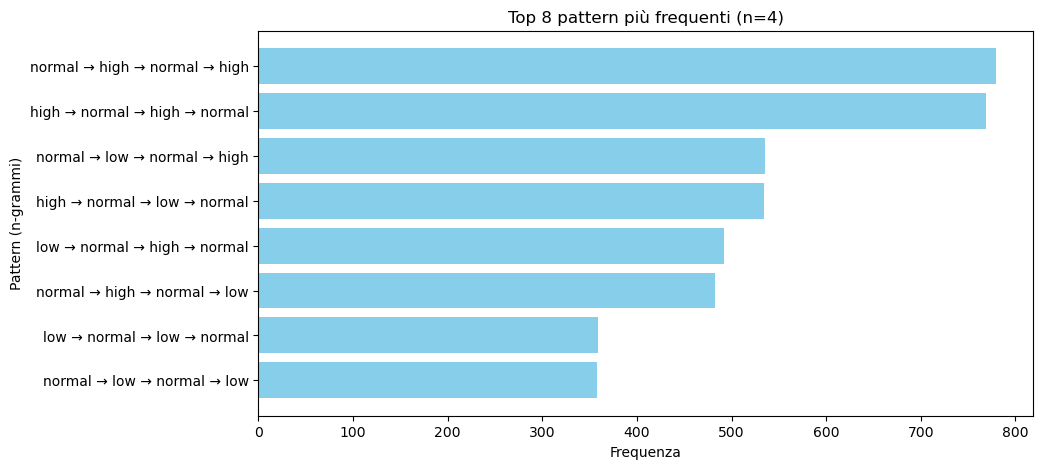

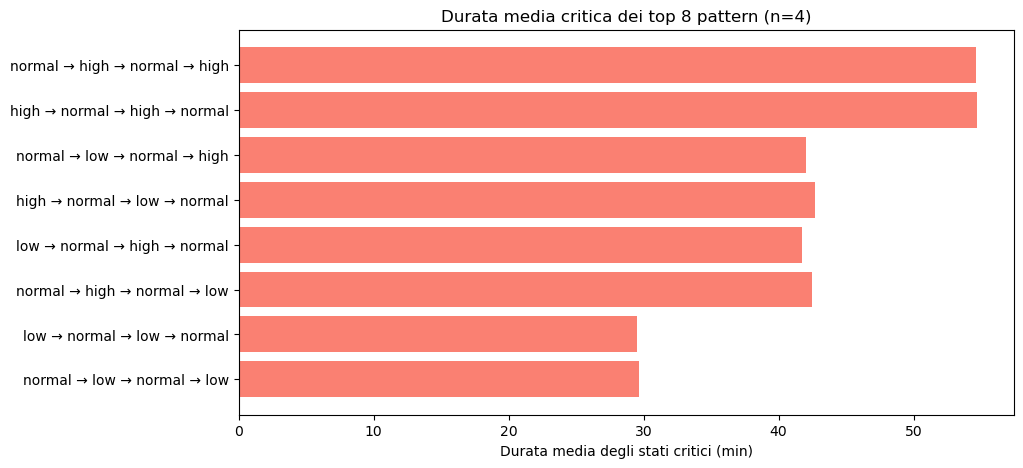

In [69]:


def simulate_sequence_with_duration(G, start="normal", steps=100):
    state = start
    seq = [(state, 210)]

    for _ in range(steps - 1):
        successors = list(G.successors(state))
        if not successors:
            break

        # Probabilità di transizione (già calcolate nel grafo)
        probs = [G[state][s]["prob"] for s in successors]
        next_state = random.choices(successors, probs)[0]

        data = G[state][next_state]

        if "mean_duration" in data:
            mean_dur = data["mean_duration"]
            dur = max(1, np.random.normal(mean_dur, mean_dur * 0.3))
        elif "durations" in data and len(data["durations"]) > 0:
            dur = random.choice(data["durations"])
        else:
            dur = random.uniform(5, 15)  # fallback

        seq.append((next_state, round(dur, 1)))
        state = next_state

    return seq


# --- Funzione per estrarre n-grammi con durate ---
def extract_ngrams(seq, n=3):
    ngrams = defaultdict(lambda: {'count': 0, 'durations': []})
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        durations = [s[1] for s in seq[i:i + n]]
        ngrams[labels]['count'] += 1
        ngrams[labels]['durations'].append(durations)
    return ngrams


# --- Analisi pattern frequenti e rari ---
def analyze_patterns_labels(seq, n=3, top_k=5):
    ngrams = defaultdict(int)
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        ngrams[labels] += 1

    results_sorted = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)

    print(f"\nTop {top_k} pattern più frequenti:")
    for labels, count in results_sorted[:top_k]:
        print(f"Pattern {labels} | count={count}")

    print(f"\nTop {top_k} pattern più rari:")
    for labels, count in results_sorted[-top_k:]:
        print(f"Pattern {labels} | count={count}")


# --- Grafico top pattern frequenti ---
def plot_top_patterns(seq, n=3, top_k=10):
    ngrams = defaultdict(int)
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        ngrams[labels] += 1

    results_sorted = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)[:top_k]

    labels = [' → '.join(r[0]) for r in results_sorted]
    counts = [r[1] for r in results_sorted]

    plt.figure(figsize=(10, 5))
    plt.barh(labels, counts, color='skyblue')
    plt.xlabel("Frequenza")
    plt.ylabel("Pattern (n-grammi)")
    plt.title(f"Top {top_k} pattern più frequenti (n={n})")
    plt.gca().invert_yaxis()
    plt.show()


# --- Grafico durata media dei pattern ---
def plot_mean_critical_duration_patterns(seq, n=3, top_k=10):
    critical_states = {"high", "low", "extremely_high", "extremely_low"}
    ngrams = extract_ngrams(seq, n=n)
    results = []

    for labels, data in ngrams.items():
        # calcola durata solo degli stati critici
        critical_durations = []
        for d in data['durations']:
            dur = sum(d[i] for i, s in enumerate(labels) if s in critical_states)
            critical_durations.append(dur)
        mean_critical = sum(critical_durations) / len(critical_durations)
        results.append((' → '.join(labels), mean_critical, data['count']))

    results_sorted = sorted(results, key=lambda x: x[2], reverse=True)[:top_k]

    plt.figure(figsize=(10, 5))
    plt.barh([r[0] for r in results_sorted], [r[1] for r in results_sorted], color='salmon')
    plt.xlabel("Durata media degli stati critici (min)")
    plt.title(f"Durata media critica dei top {top_k} pattern (n={n})")
    plt.gca().invert_yaxis()
    plt.show()


# --- Simulazione sequenza con durate ---


# --- Visualizzazione grafo probabilistico ---
def plot_probabilistic_graph(G):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, arrows=True)
    edge_labels = {(u, v): f"{data['prob']:.2f}" for u, v, data in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Modello probabilistico delle transizioni glicemiche")
    plt.show()


# sim_seq = sequenza simulata con durate
sim_seq = simulate_sequence_with_duration(G, start="normal", steps=5000)

print("\nSequenza simulata:", sim_seq)

# 1 Analisi pattern frequenti e rari
analyze_patterns_labels(sim_seq, n=4, top_k=5)

# 2 Grafico pattern più frequenti
plot_top_patterns(sim_seq, n=4, top_k=8)

# 3 Grafico durata media dei pattern
plot_mean_critical_duration_patterns(sim_seq, n=4, top_k=8)

# 4 Visualizzazione grafo probabilistico
#plot_probabilistic_graph(G)


## Confronto empirico tra dati reali e simulati


In [70]:
def state_distribution_comparison(real_seq, sim_seq):
    # Conta le frequenze
    def calc_dist(seq):
        states = [s[0] for s in seq]
        counts = Counter(states)
        total = sum(counts.values())
        return {state: (count, count / total * 100) for state, count in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_states = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Stati ===")
    print(f"{'Stato':>10} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 62)

    for state in all_states:
        real_count, real_perc = real_dist.get(state, (0, 0))
        sim_count, sim_perc = sim_dist.get(state, (0, 0))
        print(f"{state:>10} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")

    print("-" * 62)
    print(f"{'Totale':>10} | {real_total:10d}{'':>11} | {sim_total:12d}")


def transition_distribution_comparison(real_seq, sim_seq):
    def calc_dist(seq):
        transitions = [(seq[i][0], seq[i + 1][0]) for i in range(len(seq) - 1)]
        counts = Counter(transitions)
        total = sum(counts.values())
        return {t: (c, c / total * 100) for t, c in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_transitions = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Transizioni ===")
    print(f"{'Transizione':>20} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 78)

    for t in all_transitions:
        real_count, real_perc = real_dist.get(t, (0, 0))
        sim_count, sim_perc = sim_dist.get(t, (0, 0))
        tr_label = f"{t[0]} → {t[1]}"
        print(f"{tr_label:>20} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")

    print("-" * 78)
    print(f"{'Totale':>20} | {real_total:10d}{'':>11} | {sim_total:12d}")


def average_state_distribution(real_seq, sim_seq):
    # Conta le frequenze
    def calc_dist(seq):
        states = [s[0] for s in seq]
        counts = Counter(states)
        total = sum(counts.values())
        return {state: (count, count / total * 100) for state, count in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_states = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Stati ===")
    print(f"{'Stato':>10} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 62)

    for state in all_states:
        real_count, real_perc = real_dist.get(state, (0, 0))
        sim_count, sim_perc = sim_dist.get(state, (0, 0))
        print(f"{state:>10} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")

    print("-" * 62)
    print(f"{'Totale':>10} | {real_total:10d}{'':>11} | {sim_total:12d}")


def average_duration_per_state(real_seq, sim_seq):
    # Funzione interna per calcolare media per stato
    def calc_avg(seq):
        durations_per_state = defaultdict(list)
        for state, dur in seq:
            durations_per_state[state].append(dur)
        avg_per_state = {state: sum(durs) / len(durs) for state, durs in durations_per_state.items()}
        return avg_per_state

    real_avg = calc_avg(real_seq)
    sim_avg = calc_avg(sim_seq)

    all_states = sorted(set(real_avg.keys()) | set(sim_avg.keys()))

    print("\n=== Durata media per stato (minuti) ===")
    print(f"{'Stato':>15} | {'Reale':>10} | {'Simulato':>10}")
    print("-" * 40)
    for state in all_states:
        real_dur = real_avg.get(state, 0)
        sim_dur = sim_avg.get(state, 0)
        print(f"{state:>15} | {real_dur:10.2f} | {sim_dur:10.2f}")
    print("-" * 40)


# Esempio d'uso
state_distribution_comparison(seq, sim_seq)
transition_distribution_comparison(seq, sim_seq)
average_duration_per_state(seq, sim_seq)



=== Confronto Distribuzione Stati ===
     Stato |  Reale (#)  Reale (%) | Simulato (#) Simulato (%)
--------------------------------------------------------------
extremely_high |         20       3.40% |          166         3.32%
extremely_low |          2       0.34% |           16         0.32%
      high |        185      31.41% |         1575        31.50%
       low |        109      18.51% |          925        18.50%
    normal |        273      46.35% |         2318        46.36%
--------------------------------------------------------------
    Totale |        589            |         5000

=== Confronto Distribuzione Transizioni ===
         Transizione |  Reale (#)  Reale (%) | Simulato (#) Simulato (%)
------------------------------------------------------------------------------
extremely_high → high |         20       3.40% |          166         3.32%
 extremely_low → low |          2       0.34% |           16         0.32%
high → extremely_high |         20       3